In [22]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper_plots.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# FES over RMSD (overlay)

Overlay up to 10 FES profiles from `data/fes_plots` on a single plot.


In [23]:
data_dir = repo_root / 'data' / 'fes'
files = sorted(data_dir.glob('fes_*.dat'))


def mutant_from_path(path: Path) -> str:
    stem = path.stem
    if stem.startswith('fes_'):
        return stem[len('fes_'):]
    return stem.split('_', 1)[0]


selected_mutants = None  # e.g., ['WT', 'D2M', 'Y0A']

if selected_mutants:
    selected = [p for p in files if mutant_from_path(p) in selected_mutants]
else:
    selected = files


def order_selected(paths):
    wt = [p for p in paths if mutant_from_path(p) == 'WT']
    rest = [p for p in paths if mutant_from_path(p) != 'WT']
    return wt + rest


selected = order_selected(selected)[:4]
selected_names = [mutant_from_path(p) for p in selected]
selected_names


['WT', 'D2R', 'Y9E']

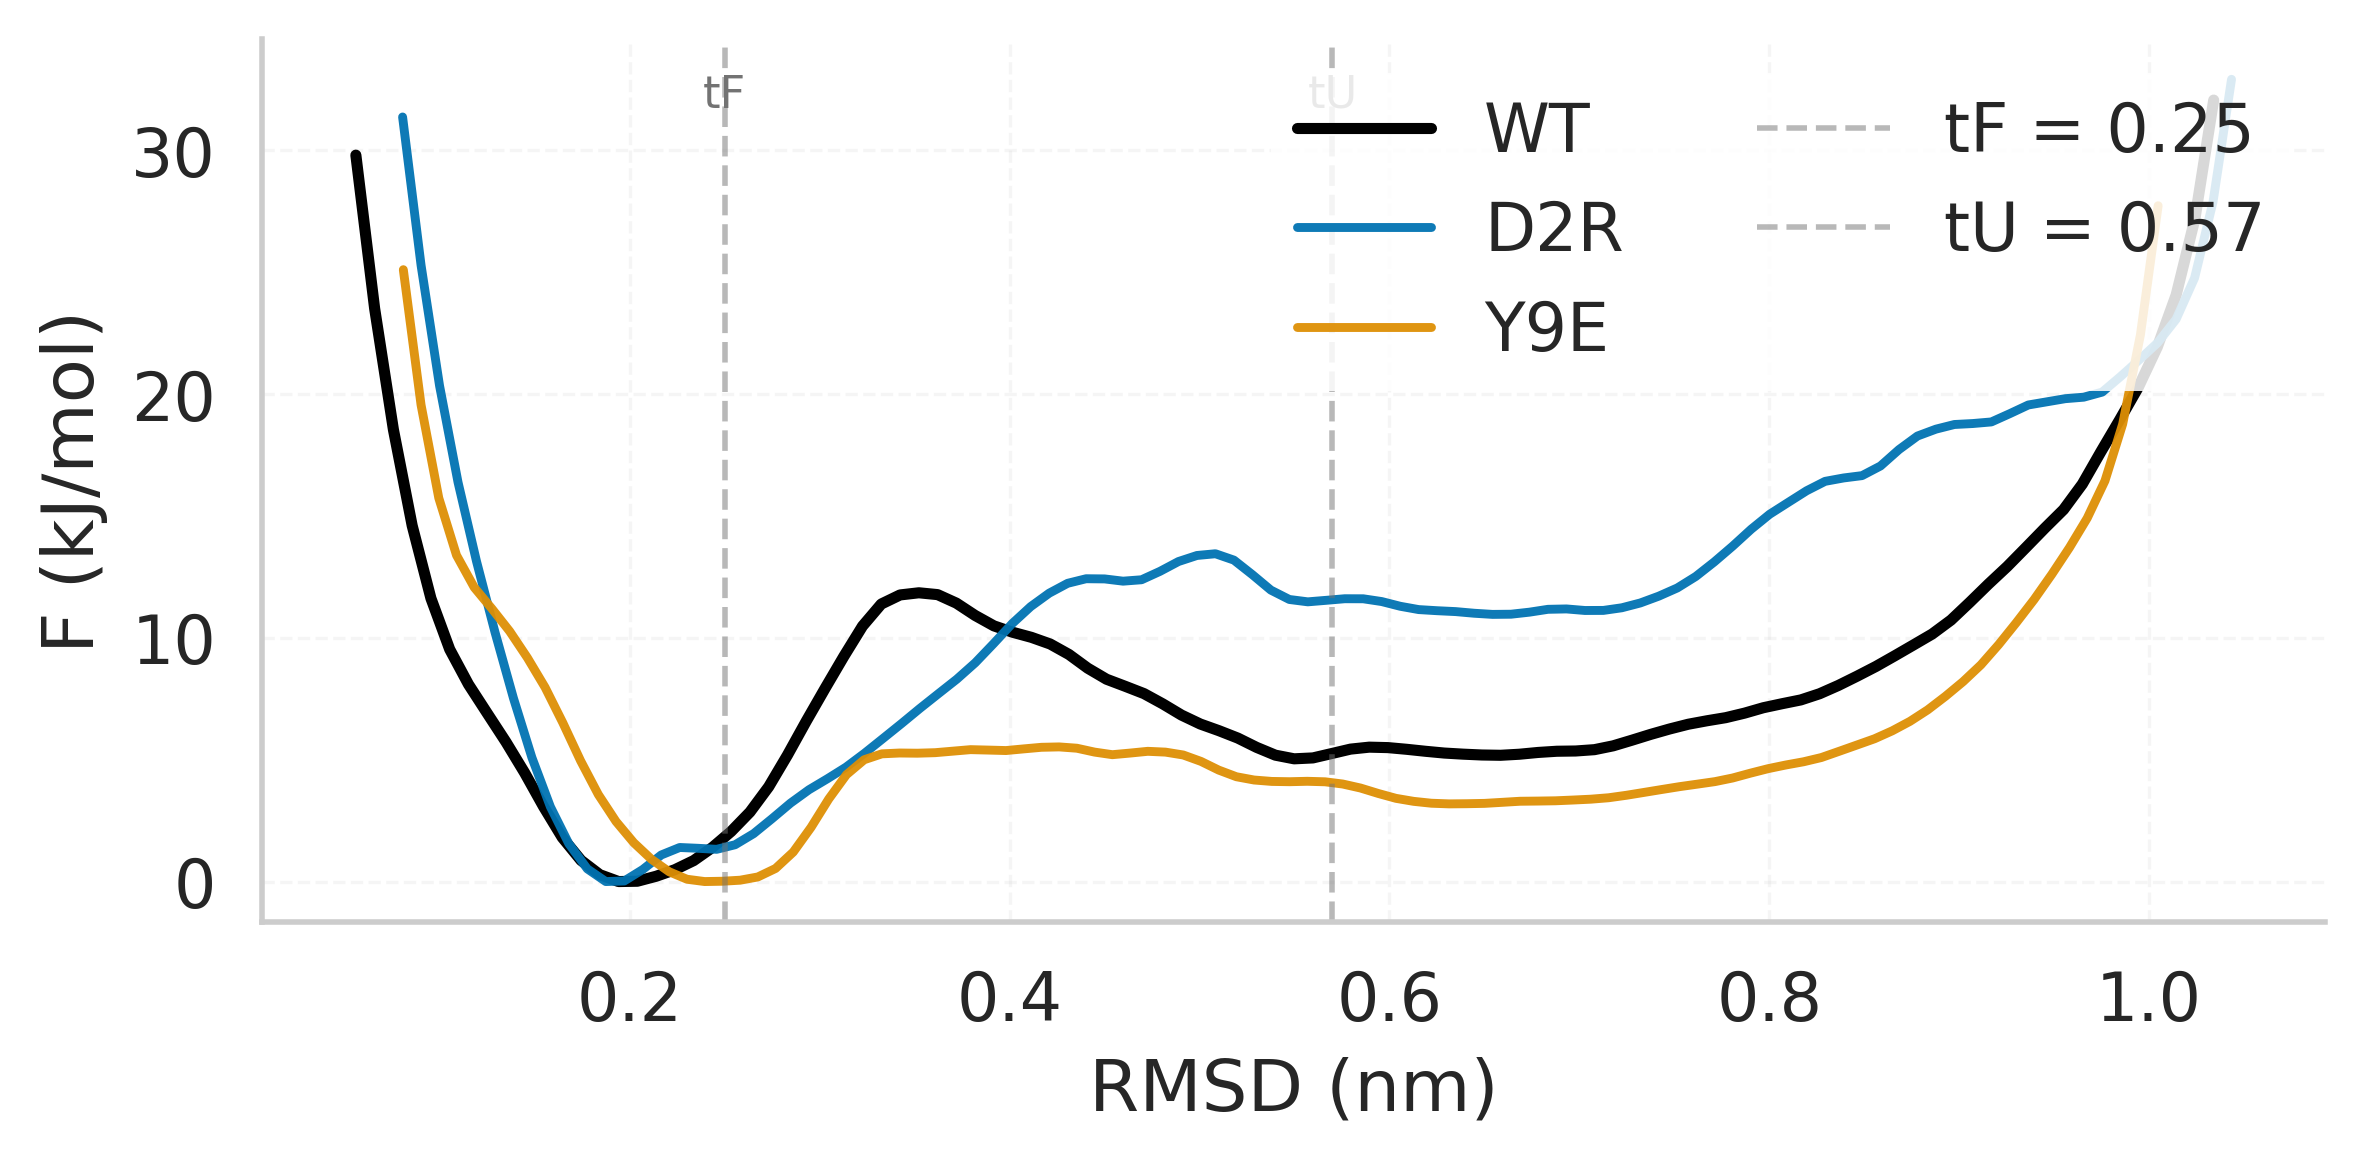

In [24]:
shift_to_min = True


def load_fes(path: Path) -> pd.DataFrame:
    # New format: whitespace-delimited .dat with columns
    # rmsd_nm free_energy_kj_per_mol
    if path.suffix == '.dat':
        return pd.read_csv(path, sep=r'\s+')

    # Legacy fallback: CSV format used in older notebook versions.
    return pd.read_csv(path)


# Paper-friendly palette: muted/colorblind-safe with WT emphasized.
base_palette = sns.color_palette('colorblind', n_colors=max(len(selected), 3))
color_map = {}
pi = 0
for name in selected_names:
    if name == 'WT':
        color_map[name] = 'black'
    else:
        color_map[name] = base_palette[pi % len(base_palette)]
        pi += 1

fig, ax = plt.subplots(figsize=(6, 3), dpi=200)

for path, name in zip(selected, selected_names):
    df = load_fes(path)

    if {'rmsd_nm', 'free_energy_kj_per_mol'}.issubset(df.columns):
        x = df['rmsd_nm']
        y = df['free_energy_kj_per_mol']
    else:
        x = df['RMSD (nm)']
        y = df['F(kJ/mol)']

    if shift_to_min:
        y = y - y.min()

    lw = 2.0 if name == 'WT' else 1.6
    alpha = 1.0 if name == 'WT' else 0.95
    ax.plot(x, y, lw=lw, alpha=alpha, color=color_map[name], label=name)


# Folding/unfolding threshold guides
tF = 0.25
tU = 0.57
guide_color = '0.45'
ax.axvline(tF, color=guide_color, linestyle='--', linewidth=1.0, alpha=0.5, label='tF = 0.25')
ax.axvline(tU, color=guide_color, linestyle='--', linewidth=1.0, alpha=0.5, label='tU = 0.57')

# Text labels on threshold lines
y_top = ax.get_ylim()[1]
ax.text(tF, 0.96 * y_top, 'tF', ha='center', va='top', color=guide_color, fontsize=8)
ax.text(tU, 0.96 * y_top, 'tU', ha='center', va='top', color=guide_color, fontsize=8)

ax.set_xlabel('RMSD (nm)')
ax.set_ylabel('F (kJ/mol)')
ax.grid(alpha=0.18, linestyle='--', linewidth=0.6)
sns.despine(ax=ax)
ax.legend(loc='upper right', bbox_to_anchor=(1.03, 1.0), ncol=2, frameon=True, facecolor='white', framealpha=0.85, edgecolor='none', borderpad=0.25, borderaxespad=0.2, labelspacing=0.25, handletextpad=0.35)
plt.tight_layout()
